# Model Evaluation

Evaluation notebook for the current single-task `ml-tau-model` checkpoints.


In [ ]:
from pathlib import Path
import sys
import importlib.util

import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from omegaconf import OmegaConf
from sklearn.metrics import confusion_matrix, roc_auc_score

plt.style.use('default')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)


In [ ]:
WORKSPACE_ROOT_CANDIDATES = [
    Path('/home/norman/ml-tau'),
    Path('/home/norman/manivald-home/ml-tau'),
]
WORKSPACE_ROOT = next((p for p in WORKSPACE_ROOT_CANDIDATES if (p / 'ml-tau-model').exists()), WORKSPACE_ROOT_CANDIDATES[-1])
MLTAU_MODEL_REPO = WORKSPACE_ROOT / 'ml-tau-model'
MLTAU_PACKAGE_DIR = MLTAU_MODEL_REPO / 'mltau'

if str(MLTAU_MODEL_REPO) not in sys.path:
    sys.path.insert(0, str(MLTAU_MODEL_REPO))
importlib.invalidate_caches()
if 'mltau' not in sys.modules:
    spec = importlib.util.spec_from_file_location(
        'mltau',
        MLTAU_PACKAGE_DIR / '__init__.py',
        submodule_search_locations=[str(MLTAU_PACKAGE_DIR)],
    )
    module = importlib.util.module_from_spec(spec)
    sys.modules['mltau'] = module
    spec.loader.exec_module(module)

from mltau.models.SingleParTau_module import ParTauModule
from mltau.tools.io.ParT_dataloader import ParticleTransformerDataset
from mltau.tools.io.general import load_row_groups
from mltau.tools import general as g
from mltau.tools.evaluation import decay_mode as dm_eval
from mltau.tools.evaluation import tagging as tag_eval


In [80]:
DATA_BASE_DIR = Path('/scratch/persistent/norman/ml-tau/cld/v1.2.5_key4hep_2025-05-29/260401')
SAMPLE_NAMES = {
    'signal': 'z_test',
    'background': 'qq_test',
}

CHECKPOINTS = {
    'charge': WORKSPACE_ROOT / 'training_outputs/260401_charge/models/ParT-model_best.ckpt',
    'decay_mode': WORKSPACE_ROOT / 'training_outputs/260401_DM/models/ParT-model_best.ckpt',
    'kinematics': WORKSPACE_ROOT / 'training_outputs/260401_kin/models/ParT-model_best.ckpt',
    'is_tau': WORKSPACE_ROOT / 'training_outputs/260401_isTau/models/ParT-epoch=59.ckpt',
}

for name, path in CHECKPOINTS.items():
    print(f'{name:>10}: {path} exists={path.exists()}')


    charge: /home/norman/ml-tau/training_outputs/260401_charge/models/ParT-model_best.ckpt exists=True
decay_mode: /home/norman/ml-tau/training_outputs/260401_DM/models/ParT-model_best.ckpt exists=True
kinematics: /home/norman/ml-tau/training_outputs/260401_kin/models/ParT-model_best.ckpt exists=True
    is_tau: /home/norman/ml-tau/training_outputs/260401_isTau/models/ParT-epoch=59.ckpt exists=True


In [81]:
_SAMPLE_CACHE = {}

def resolve_sample_path(base_dir: Path, sample_name: str) -> Path:
    candidates = [base_dir / f'{sample_name}.parquet', base_dir / sample_name]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not resolve sample {sample_name!r} under {base_dir}')

def load_sample(sample_name: str):
    if sample_name not in _SAMPLE_CACHE:
        _SAMPLE_CACHE[sample_name] = ak.from_parquet(resolve_sample_path(DATA_BASE_DIR, sample_name))
    return _SAMPLE_CACHE[sample_name]

def to_p4(p4_obj):
    return g.reinitialize_p4(p4_obj)

def wrap_delta_phi(delta_phi):
    return np.arctan2(np.sin(delta_phi), np.cos(delta_phi))

def q50(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    return np.quantile(values, 0.5) if values.size else np.nan

def iqr(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    q25, q75 = np.quantile(values, [0.25, 0.75])
    return q75 - q25

def iqr_over_q50(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    q25, q50, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    return (q75 - q25) / q50 if q50 != 0 else np.nan

def compute_binned_stat(x, bins, y, stat_fn):
    x = np.asarray(x)
    y = np.asarray(y)
    centers = 0.5 * (bins[:-1] + bins[1:])
    stats = []
    counts = []
    for left, right in zip(bins[:-1], bins[1:]):
        mask = (x >= left) & (x < right) & np.isfinite(x) & np.isfinite(y)
        counts.append(int(mask.sum()))
        stats.append(stat_fn(y[mask]) if mask.any() else np.nan)
    return centers, np.asarray(stats), np.asarray(counts)

def load_cfg(task: str):
    cfg = OmegaConf.merge(
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/main.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/dataset.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/training.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/metrics.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/tagging.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/charge.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/decay_mode.yaml'),
        OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/kinematics.yaml'),
    )
    cfg.training.model.name = 'SingleParTau'
    cfg.training.model.task = task
    cfg.training.dataloader.num_dataloader_workers = 0
    cfg.dataset.data_dir = str(DATA_BASE_DIR)
    return cfg

def infer_single_task(task: str, checkpoint_path: Path, sample_name: str, batch_size: int = 2048):
    sample_path = resolve_sample_path(DATA_BASE_DIR, sample_name)
    raw = load_sample(sample_name)
    cfg = load_cfg(task)
    model = ParTauModule(cfg=cfg, input_dim=13, num_dm_classes=6, task=task)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE)
    model.eval()
    row_groups = load_row_groups(str(sample_path))
    dataset = ParticleTransformerDataset(row_groups=row_groups, device=DEVICE.type, cfg=cfg)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, num_workers=0)
    predictions_acc = {}
    targets_acc = {}
    with torch.no_grad():
        for batch in loader:
            predictions, targets, _ = model.forward(batch)
            for key, value in predictions.items():
                predictions_acc.setdefault(key, []).append(np.asarray(value.detach().cpu()))
            for key, value in targets.items():
                targets_acc.setdefault(key, []).append(np.asarray(value.detach().cpu()))
    predictions_acc = {key: np.concatenate(values, axis=0) for key, values in predictions_acc.items()}
    targets_acc = {key: np.concatenate(values, axis=0) for key, values in targets_acc.items()}
    if len(raw) != len(next(iter(predictions_acc.values()))):
        raise RuntimeError(f'Length mismatch for {task}')
    return raw, predictions_acc, targets_acc, cfg


## Charge

In [101]:
def jet_charge_qkappa(charges, pts, jet_pts, kappa=0.5):
    numer = ak.sum(charges * (pts ** kappa), axis=1)
    denom = jet_pts ** kappa
    denom = ak.where(denom == 0, 1.0, denom)
    return ak.to_numpy(numer / denom)

def compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds):
    score = np.asarray(score)
    true_charge_signed = np.asarray(true_charge_signed)
    eff_pos, eff_neg = [], []
    fake_pos_from_neg, fake_neg_from_pos = [], []
    for thr in thresholds:
        pred_charge = np.where(score >= thr, 1, -1)
        pos_mask = true_charge_signed == 1
        neg_mask = true_charge_signed == -1
        eff_pos.append(np.mean(pred_charge[pos_mask] == 1) if np.any(pos_mask) else np.nan)
        eff_neg.append(np.mean(pred_charge[neg_mask] == -1) if np.any(neg_mask) else np.nan)
        fake_pos_from_neg.append(np.mean(pred_charge[neg_mask] == 1) if np.any(neg_mask) else np.nan)
        fake_neg_from_pos.append(np.mean(pred_charge[pos_mask] == -1) if np.any(pos_mask) else np.nan)
    return {
        'thresholds': np.asarray(thresholds),
        'eff_pos': np.asarray(eff_pos),
        'eff_neg': np.asarray(eff_neg),
        'fake_pos_from_neg': np.asarray(fake_pos_from_neg),
        'fake_neg_from_pos': np.asarray(fake_neg_from_pos),
        'avg_eff': 0.5 * (np.asarray(eff_pos) + np.asarray(eff_neg)),
        'avg_fake': 0.5 * (np.asarray(fake_pos_from_neg) + np.asarray(fake_neg_from_pos)),
    }

def choose_threshold_for_target_avg_fake(score, true_charge_signed, thresholds, target_avg_fake_rate=1e-2):
    curve = compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds)
    idx = int(np.nanargmin(np.abs(curve['avg_fake'] - target_avg_fake_rate)))
    return {
        'threshold': float(curve['thresholds'][idx]),
        'avg_eff': float(curve['avg_eff'][idx]),
        'avg_fake': float(curve['avg_fake'][idx]),
    }

def compute_binned_charge_efficiencies(values, bins, score, true_charge_signed, threshold):
    values = np.asarray(values)
    score = np.asarray(score)
    true_charge_signed = np.asarray(true_charge_signed)
    pred_charge = np.where(score >= threshold, 1, -1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    pos_eff = []
    neg_eff = []
    for left, right in zip(bins[:-1], bins[1:]):
        mask = (values >= left) & (values < right)
        pos_mask = mask & (true_charge_signed == 1)
        neg_mask = mask & (true_charge_signed == -1)
        pos_eff.append(np.mean(pred_charge[pos_mask] == 1) if np.any(pos_mask) else np.nan)
        neg_eff.append(np.mean(pred_charge[neg_mask] == -1) if np.any(neg_mask) else np.nan)
    return {'centers': centers, 'pos_eff': np.asarray(pos_eff), 'neg_eff': np.asarray(neg_eff)}


def compute_binned_charge_fake_rates(values, bins, score, true_charge_signed, threshold):
    values = np.asarray(values)
    score = np.asarray(score)
    true_charge_signed = np.asarray(true_charge_signed)
    pred_charge = np.where(score >= threshold, 1, -1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    fake_pos = []
    fake_neg = []
    for left, right in zip(bins[:-1], bins[1:]):
        mask = (values >= left) & (values < right)
        neg_mask = mask & (true_charge_signed == -1)
        pos_mask = mask & (true_charge_signed == 1)
        fake_pos.append(np.mean(pred_charge[neg_mask] == 1) if np.any(neg_mask) else np.nan)
        fake_neg.append(np.mean(pred_charge[pos_mask] == -1) if np.any(pos_mask) else np.nan)
    return {'centers': centers, 'fake_pos': np.asarray(fake_pos), 'fake_neg': np.asarray(fake_neg)}

def choose_threshold_for_target_avg_eff(score, true_charge_signed, thresholds, target_avg_eff=0.8):
    curve = compute_average_efficiency_and_fake_curve(score, true_charge_signed, thresholds)
    idx = int(np.nanargmin(np.abs(curve['avg_eff'] - target_avg_eff)))
    return {
        'threshold': float(curve['thresholds'][idx]),
        'avg_eff': float(curve['avg_eff'][idx]),
        'avg_fake': float(curve['avg_fake'][idx]),
    }


def compare_fake_rate_at_matched_efficiency(reference_eff, candidate_eff, candidate_fake, eff_grid):
    reference_eff = np.asarray(reference_eff)
    candidate_eff = np.asarray(candidate_eff)
    candidate_fake = np.asarray(candidate_fake)
    eff_grid = np.asarray(eff_grid)
    matched_fake = np.full_like(eff_grid, np.nan, dtype=float)
    for i, target_eff in enumerate(eff_grid):
        idx = np.nanargmin(np.abs(candidate_eff - target_eff))
        matched_fake[i] = candidate_fake[idx]
    return matched_fake


In [83]:
charge_raw, charge_predictions, charge_targets, charge_cfg = infer_single_task('charge', CHECKPOINTS['charge'], SAMPLE_NAMES['signal'])
charge_score = np.asarray(charge_predictions['charge'])
charge_truth = np.asarray(charge_targets['charge']).astype(int)
charge_truth_signed = np.where(charge_truth == 1, 1, -1)
charge_pf_charges = charge_raw.reco_cand_charge
charge_pf_pts = to_p4(charge_raw.reco_cand_p4s).pt
charge_jet_pts = to_p4(charge_raw.reco_jet_p4s).pt
charge_gen_tau_pt = ak.to_numpy(to_p4(charge_raw.gen_jet_tau_p4s).pt)

kappa_values = np.round(np.arange(0.1, 1.6, 0.1), 2)
kappa_rows = []
qkappa_scores = {}
for kappa in kappa_values:
    qkappa_scores[float(kappa)] = jet_charge_qkappa(charge_pf_charges, charge_pf_pts, charge_jet_pts, float(kappa))
    score = np.asarray(qkappa_scores[float(kappa)])
    kappa_rows.append({
        'kappa': float(kappa),
        'auc': roc_auc_score(charge_truth, score),
        'accuracy': np.mean((score >= 0.0).astype(int) == charge_truth),
    })
kappa_scan_df = pd.DataFrame(kappa_rows).sort_values('auc', ascending=False).reset_index(drop=True)
best_kappa = float(kappa_scan_df.loc[0, 'kappa'])
best_kappa_label = f'{best_kappa:.2f}'.rstrip('0').rstrip('.')
charge_qk = np.asarray(qkappa_scores[best_kappa])
charge_qk_prob = np.clip(0.5 * (charge_qk + 1.0), 0.0, 1.0)
model_thresholds = np.linspace(0.0, 1.0, 2001)
qk_thresholds = np.linspace(np.min(charge_qk), np.max(charge_qk), 2001)
model_curve = compute_average_efficiency_and_fake_curve(charge_score, charge_truth_signed, model_thresholds)
qk_curve = compute_average_efficiency_and_fake_curve(charge_qk, charge_truth_signed, qk_thresholds)
model_wp = choose_threshold_for_target_avg_fake(charge_score, charge_truth_signed, model_thresholds, 1e-2)
qk_wp = choose_threshold_for_target_avg_fake(charge_qk, charge_truth_signed, qk_thresholds, 1e-2)
charge_pt_bins = np.array([10, 20, 30, 40, 50, 60])
display(kappa_scan_df)
display(pd.DataFrame({
    'threshold': [model_wp['threshold'], qk_wp['threshold']],
    'avg_eff': [model_wp['avg_eff'], qk_wp['avg_eff']],
    'avg_fake': [model_wp['avg_fake'], qk_wp['avg_fake']],
}, index=['model', rf'Q_kappa({best_kappa_label})']))


There are 118,028 jets in the dataset.


,kappa,auc,accuracy
0,0.1000,0.9811,0.9251
1,0.2000,0.9811,0.9251
2,0.3000,0.9803,0.9232
3,0.4000,0.9779,0.9176
4,0.5000,0.9744,0.9110
5,0.6000,0.9702,0.9055
6,0.7000,0.9654,0.9004
7,0.8000,0.9607,0.8965
8,0.9000,0.9563,0.8936
9,1.0000,0.9522,0.8909


,threshold,avg_eff,avg_fake
model,0.4810,0.9557,0.0443
Q_kappa(0.1),0.2146,0.9270,0.0730


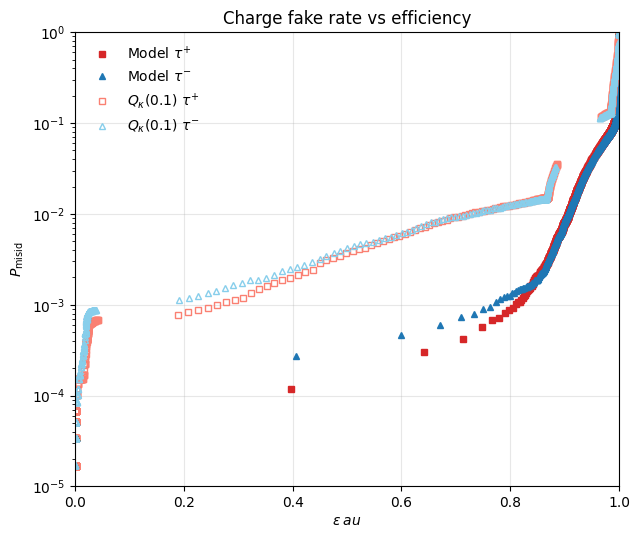

In [84]:
plt.figure(figsize=(6.5, 5.5))
plt.plot(model_curve['eff_pos'], model_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.5, color='tab:red', label=r'Model $\tau^{+}$')
plt.plot(model_curve['eff_neg'], model_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.5, color='tab:blue', label=r'Model $\tau^{-}$')
plt.plot(qk_curve['eff_pos'], qk_curve['fake_pos_from_neg'], linestyle='None', marker='s', markersize=4.0, markerfacecolor='none', markeredgecolor='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.plot(qk_curve['eff_neg'], qk_curve['fake_neg_from_pos'], linestyle='None', marker='^', markersize=4.0, markerfacecolor='none', markeredgecolor='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'$\epsilon_	au$')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title('Charge fake rate vs efficiency')
plt.yscale('log')
plt.xlim(0.0, 1.0)
plt.ylim(1e-5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


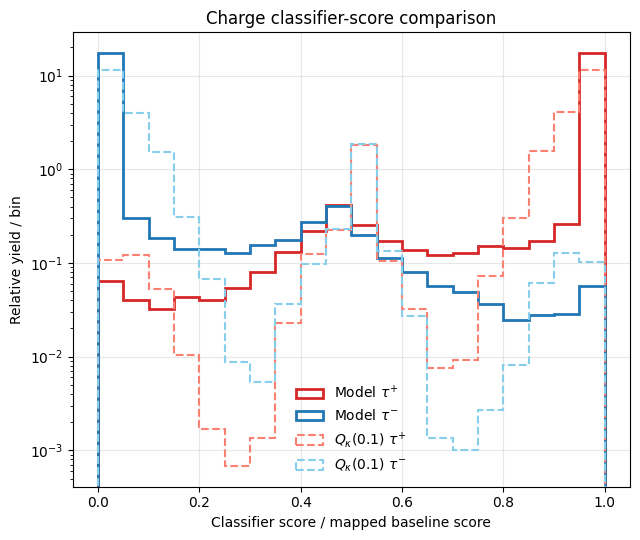

In [85]:
score_bins = np.linspace(0.0, 1.0, 21)
plt.figure(figsize=(6.5, 5.5))
plt.hist(charge_score[charge_truth_signed == 1], bins=score_bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label=r'Model $\tau^{+}$')
plt.hist(charge_score[charge_truth_signed == -1], bins=score_bins, density=True, histtype='step', linewidth=2.0, color='tab:blue', label=r'Model $\tau^{-}$')
plt.hist(charge_qk_prob[charge_truth_signed == 1], bins=score_bins, density=True, histtype='step', linewidth=1.5, linestyle='--', color='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.hist(charge_qk_prob[charge_truth_signed == -1], bins=score_bins, density=True, histtype='step', linewidth=1.5, linestyle='--', color='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel('Classifier score / mapped baseline score')
plt.ylabel('Relative yield / bin')
plt.yscale('log')
plt.title('Charge classifier-score comparison')
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


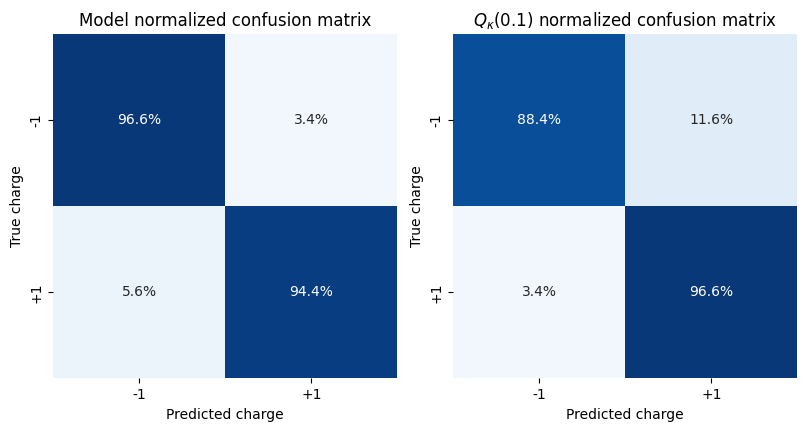

In [86]:
cm_model = confusion_matrix(charge_truth_signed, np.where(charge_score >= 0.5, 1, -1), labels=[-1, 1], normalize='true')
cm_qk = confusion_matrix(charge_truth_signed, np.where(charge_qk >= 0.0, 1, -1), labels=[-1, 1], normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), constrained_layout=True)
for ax, cm, title in [
    (axes[0], cm_model, 'Model normalized confusion matrix'),
    (axes[1], cm_qk, rf'$Q_\kappa({best_kappa_label})$ normalized confusion matrix'),
]:
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues', vmin=0.0, vmax=1.0, cbar=False, square=True, ax=ax)
    ax.set_xticklabels(['-1', '+1'])
    ax.set_yticklabels(['-1', '+1'])
    ax.set_xlabel('Predicted charge')
    ax.set_ylabel('True charge')
    ax.set_title(title)
    ax.set_box_aspect(1)
plt.show()


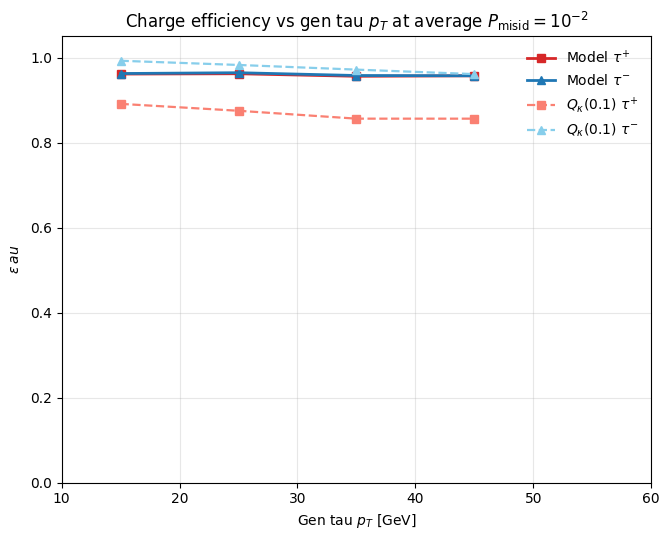

In [87]:
model_eff = compute_binned_charge_efficiencies(charge_gen_tau_pt, charge_pt_bins, charge_score, charge_truth_signed, model_wp['threshold'])
qk_eff = compute_binned_charge_efficiencies(charge_gen_tau_pt, charge_pt_bins, charge_qk, charge_truth_signed, qk_wp['threshold'])

plt.figure(figsize=(6.8, 5.5))
plt.plot(model_eff['centers'], model_eff['pos_eff'], marker='s', linewidth=2.0, color='tab:red', label=r'Model $\tau^{+}$')
plt.plot(model_eff['centers'], model_eff['neg_eff'], marker='^', linewidth=2.0, color='tab:blue', label=r'Model $\tau^{-}$')
plt.plot(qk_eff['centers'], qk_eff['pos_eff'], marker='s', linewidth=1.6, linestyle='--', color='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$')
plt.plot(qk_eff['centers'], qk_eff['neg_eff'], marker='^', linewidth=1.6, linestyle='--', color='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$')
plt.xlabel(r'Gen tau $p_T$ [GeV]')
plt.ylabel(r'$\epsilon_	au$')
plt.title(r'Charge efficiency vs gen tau $p_T$ at average $P_{\mathrm{misid}} = 10^{-2}$')
plt.xlim(10, 60)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


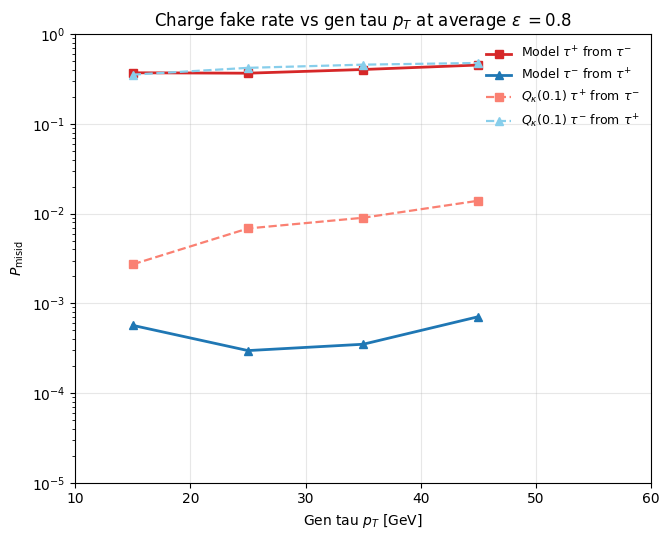

In [112]:
target_avg_efficiency = 0.8
model_eff_wp = choose_threshold_for_target_avg_eff(charge_score, charge_truth_signed, model_thresholds, target_avg_efficiency)
qk_eff_wp = choose_threshold_for_target_avg_eff(charge_qk, charge_truth_signed, qk_thresholds, target_avg_efficiency)

model_fake = compute_binned_charge_fake_rates(charge_gen_tau_pt, charge_pt_bins, charge_score, charge_truth_signed, model_eff_wp['threshold'])
qk_fake = compute_binned_charge_fake_rates(charge_gen_tau_pt, charge_pt_bins, charge_qk, charge_truth_signed, qk_eff_wp['threshold'])

plt.figure(figsize=(6.8, 5.5))
plt.plot(model_fake['centers'], model_fake['fake_pos'], marker='s', linewidth=2.0, color='tab:red', label=r'Model $\tau^{+}$ from $\tau^{-}$')
plt.plot(model_fake['centers'], model_fake['fake_neg'], marker='^', linewidth=2.0, color='tab:blue', label=r'Model $\tau^{-}$ from $\tau^{+}$')
plt.plot(qk_fake['centers'], qk_fake['fake_pos'], marker='s', linewidth=1.6, linestyle='--', color='salmon', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{+}}$ from $\tau^{{-}}$')
plt.plot(qk_fake['centers'], qk_fake['fake_neg'], marker='^', linewidth=1.6, linestyle='--', color='skyblue', label=rf'$Q_\kappa({best_kappa_label})$ $\tau^{{-}}$ from $\tau^{{+}}$')
plt.xlabel(r'Gen tau $p_T$ [GeV]')
plt.ylabel(r'$P_{\mathrm{misid}}$')
plt.title(r'Charge fake rate vs gen tau $p_T$ at average $\epsilon_ = 0.8$')
plt.xlim(10, 60)
plt.yscale('log')
plt.ylim(1e-5, 1.0)
plt.grid(True, alpha=0.3)
plt.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## Decay Mode

In [88]:
dm_raw, dm_predictions, dm_targets, dm_cfg = infer_single_task('decay_mode', CHECKPOINTS['decay_mode'], SAMPLE_NAMES['signal'])
dm_predictions_proba = np.asarray(dm_predictions['decay_mode'])
dm_targets_class = np.argmax(np.asarray(dm_targets['decay_mode']), axis=-1)
dm_predictions_class = np.argmax(dm_predictions_proba, axis=-1)
dm_evaluator = dm_eval.DecayModeEvaluator(predicted=dm_predictions_class, truth=dm_targets_class, output_dir='', sample='all', algorithm='all')
display(pd.DataFrame([dm_evaluator.general_metrics]))


There are 118,028 jets in the dataset.


,FPR,FNR,TPR,TNR,precision,accuracy,recall,F1
0,0.0141,0.0141,0.1526,1.0000,0.9154,0.9761,0.9154,0.9154


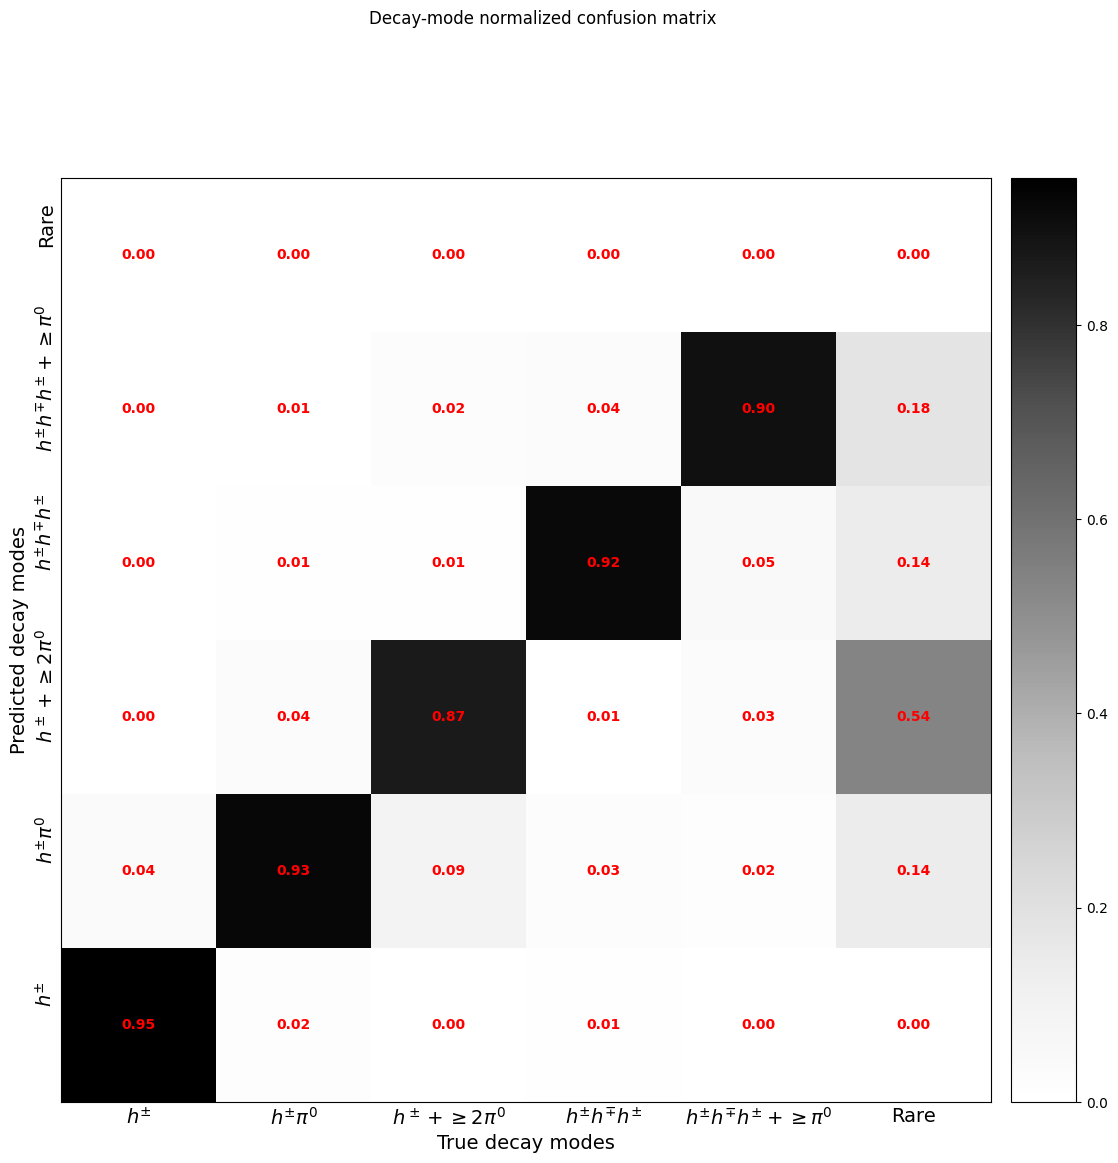

In [89]:
cm_fig, _ = dm_evaluator.plot_confusion_matrix()
cm_fig.suptitle('Decay-mode normalized confusion matrix', y=1.02)
plt.show()


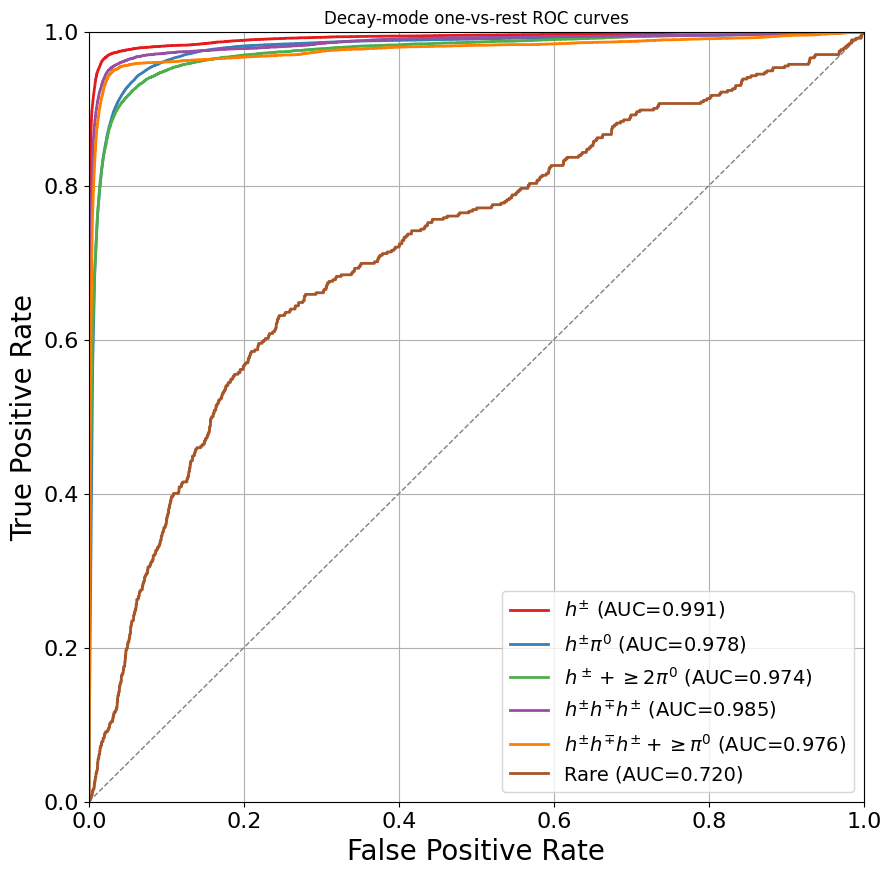

In [90]:
dm_roc_plot = dm_eval.DecayModeROCPlot(predictions_proba=dm_predictions_proba, targets=dm_targets_class, categories=dm_evaluator.categories)
dm_roc_plot.ax.set_title('Decay-mode one-vs-rest ROC curves')
plt.show()


### Decay-Mode Migration Plot

For each true generator decay mode, the stacked bar shows how the predictions are distributed across output classes. Each bar sums to 100%, so you can directly see where the missing fraction goes.


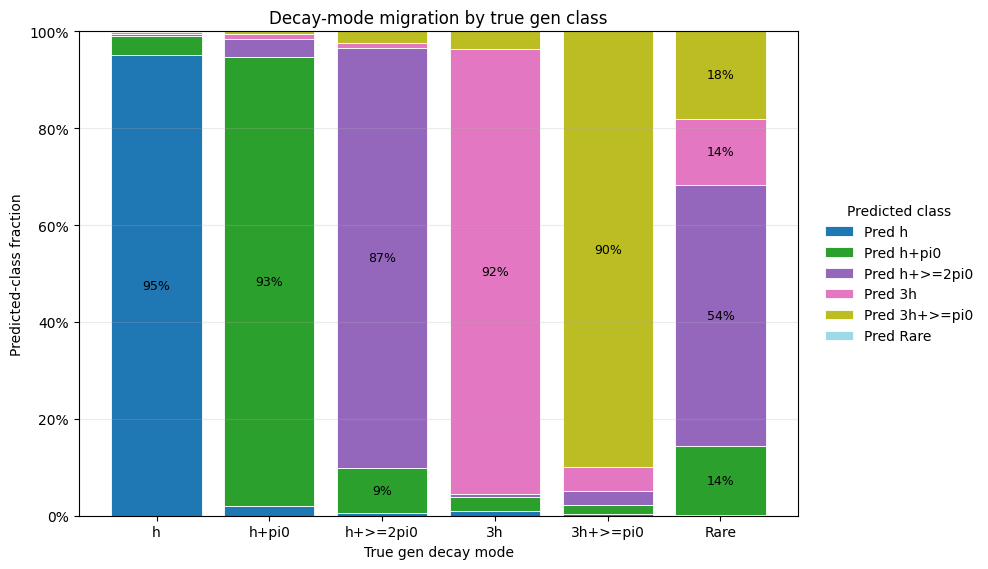

In [120]:
dm_pretty_labels = {
    0: '1p0pi0',
    1: '1p1pi0',
    2: '1p2pi0',
    10: '3p0pi0',
    11: '3p1pi0',
    15: 'Rare',
}

cm_counts = confusion_matrix(dm_targets_class, dm_predictions_class, labels=np.arange(len(dm_evaluator.categories)))
cm_frac = cm_counts / np.clip(cm_counts.sum(axis=1, keepdims=True), 1, None)

category_ids = list(dm_evaluator.categories)

def pretty_dm_label(cat):
    try:
        return dm_pretty_labels.get(int(cat), str(cat))
    except (TypeError, ValueError):
        label = str(cat)
        replacements = {
            '$': '',
            '\pm': '',
            '\geq': '>=',
            '\pi^0': 'pi0',
            '\pi0': 'pi0',
            '\pi': 'pi',
            '{': '',
            '}': '',
            '^': '',
            '\\': '',
        }
        for old_token, new_token in replacements.items():
            label = label.replace(old_token, new_token)
        label = label.replace('hpi0', 'h+pi0')
        label = label.replace('h+>=2pi0', 'h+>=2pi0')
        label = label.replace('hhmph', '3h')
        label = label.replace('hhmhphpi0', '3h+pi0')
        label = label.replace('hhmph+>=pi0', '3h+>=pi0')
        label = label.replace('RareDecayMode', 'Rare')
        label = ' '.join(label.split())
        return label

category_labels = [pretty_dm_label(cat) for cat in category_ids]
x = np.arange(len(category_labels))
colors = plt.cm.tab20(np.linspace(0, 1, len(category_labels)))

fig, ax = plt.subplots(figsize=(10, 5.8))
bottom = np.zeros(len(category_labels))
for pred_idx, (label, color) in enumerate(zip(category_labels, colors)):
    vals = cm_frac[:, pred_idx]
    bars = ax.bar(
        x, vals, bottom=bottom, color=color, edgecolor='white', linewidth=0.6,
        label=f'Pred {label}'
    )
    for true_idx, (bar, frac) in enumerate(zip(bars, vals)):
        if frac >= 0.06:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[true_idx] + frac / 2,
                f'{100*frac:.0f}%',
                ha='center', va='center', fontsize=9, color='black'
            )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(category_labels, rotation=0)
ax.set_xlabel('True gen decay mode')
ax.set_ylabel('Predicted-class fraction')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_yticklabels([f'{int(100*t)}%' for t in np.linspace(0, 1, 6)])
ax.set_title('Decay-mode migration by true gen class')
ax.grid(True, axis='y', alpha=0.25)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, title='Predicted class')
plt.tight_layout()
plt.show()


### Decay-Mode Misclassification vs $p_T$

Misclassification rate as a function of true tau $p_T$, split by the true decay mode. This shows whether specific decay modes become harder to classify in certain kinematic regions.


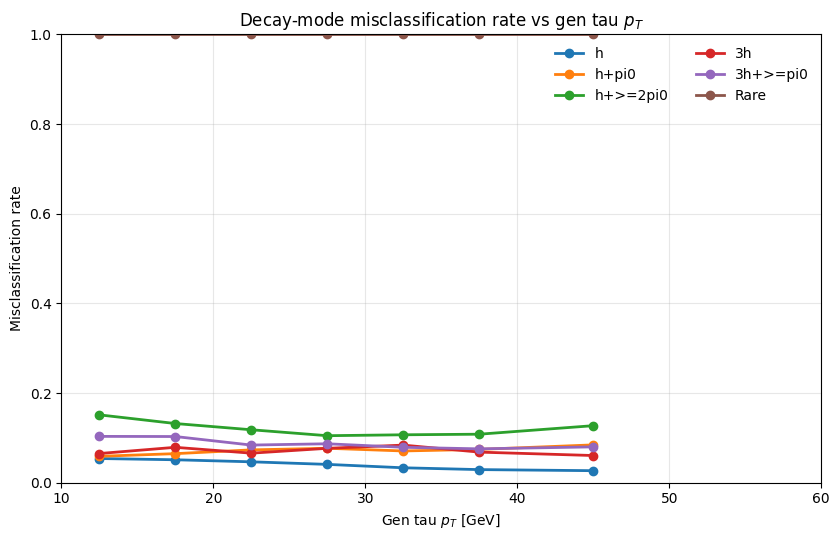

In [122]:
dm_true_pt = ak.to_numpy(to_p4(dm_raw.gen_jet_tau_p4s).pt)
dm_pt_bins = np.array([10, 15, 20, 25, 30, 35, 40, 50, 60])
dm_centers = 0.5 * (dm_pt_bins[:-1] + dm_pt_bins[1:])

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for class_idx, class_id in enumerate(category_ids):
    true_mask = dm_targets_class == class_idx
    misid = []
    for left, right in zip(dm_pt_bins[:-1], dm_pt_bins[1:]):
        mask = true_mask & (dm_true_pt >= left) & (dm_true_pt < right)
        if np.any(mask):
            misid.append(np.mean(dm_predictions_class[mask] != dm_targets_class[mask]))
        else:
            misid.append(np.nan)
    ax.plot(dm_centers, misid, marker='o', linewidth=2.0, label=pretty_dm_label(class_id))

ax.set_xlabel(r'Gen tau $p_T$ [GeV]')
ax.set_ylabel('Misclassification rate')
ax.set_title('Decay-mode misclassification rate vs gen tau $p_T$')
ax.set_xlim(10, 60)
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


### Decay-Mode Flow Plot

A stacked migration plot is more suitable for paper-style presentation than the Sankey view, so use the stacked plot above as the default summary.


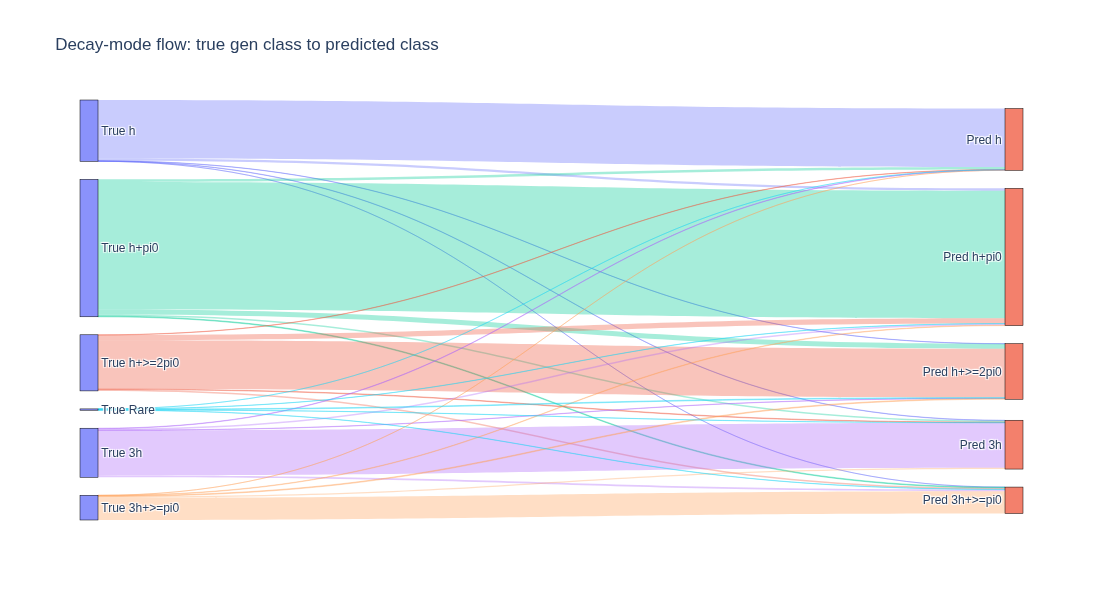

In [121]:
try:
    import plotly.graph_objects as go
except ImportError:
    print('plotly is not installed in this environment')
else:
    true_labels = [f'True {pretty_dm_label(cat)}' for cat in category_ids]
    pred_labels = [f'Pred {pretty_dm_label(cat)}' for cat in category_ids]
    labels = true_labels + pred_labels

    source = []
    target = []
    value = []
    link_color = []
    node_colors = ['rgba(99, 110, 250, 0.75)'] * len(true_labels) + ['rgba(239, 85, 59, 0.75)'] * len(pred_labels)

    palette = [
        'rgba(99, 110, 250, 0.35)',
        'rgba(0, 204, 150, 0.35)',
        'rgba(239, 85, 59, 0.35)',
        'rgba(171, 99, 250, 0.35)',
        'rgba(255, 161, 90, 0.35)',
        'rgba(25, 211, 243, 0.35)',
        'rgba(255, 102, 146, 0.35)',
        'rgba(182, 232, 128, 0.35)',
    ]

    for i_true in range(cm_counts.shape[0]):
        for j_pred in range(cm_counts.shape[1]):
            if cm_counts[i_true, j_pred] <= 0:
                continue
            source.append(i_true)
            target.append(len(true_labels) + j_pred)
            value.append(int(cm_counts[i_true, j_pred]))
            link_color.append(palette[i_true % len(palette)])

    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=18,
            thickness=18,
            line=dict(color='black', width=0.5),
            label=labels,
            color=node_colors,
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=link_color,
        )
    )])

    fig.update_layout(
        title='Decay-mode flow: true gen class to predicted class',
        font=dict(size=12),
        width=1000,
        height=600,
    )
    fig.show()


## Kinematics

In [91]:
kin_raw, kin_predictions, kin_targets, kin_cfg = infer_single_task('kinematics', CHECKPOINTS['kinematics'], SAMPLE_NAMES['signal'])
kin_signal_mask = np.asarray(kin_targets['is_tau']).astype(bool)
kin_pred = np.asarray(kin_predictions['kinematics'])[kin_signal_mask]
kin_reco = to_p4(kin_raw.reco_jet_p4s)[kin_signal_mask]
kin_gen = to_p4(kin_raw.gen_jet_tau_p4s)[kin_signal_mask]
kin_reco_pt = ak.to_numpy(kin_reco.pt)
kin_reco_eta = ak.to_numpy(kin_reco.eta)
kin_reco_phi = ak.to_numpy(kin_reco.phi)
kin_reco_mass = ak.to_numpy(kin_reco.mass)
kin_true_pt = ak.to_numpy(kin_gen.pt)
kin_true_eta = ak.to_numpy(kin_gen.eta)
kin_true_phi = ak.to_numpy(kin_gen.phi)
kin_true_mass = ak.to_numpy(kin_gen.mass)
kin_pred_pt = np.exp(kin_pred[:, 0]) * kin_reco_pt
kin_pred_eta = kin_pred[:, 1] + kin_reco_eta
kin_pred_phi = wrap_delta_phi(kin_pred[:, 2] + kin_reco_phi)
kin_pred_mass = np.exp(kin_pred[:, 3]) * kin_reco_mass
kin_pt_ratio_model = kin_pred_pt / kin_true_pt
kin_pt_ratio_reco = kin_reco_pt / kin_true_pt
kin_mass_ratio_model = kin_pred_mass / kin_true_mass
kin_mass_ratio_reco = kin_reco_mass / kin_true_mass
kin_eta_residual_model = kin_pred_eta - kin_true_eta
kin_eta_residual_reco = kin_reco_eta - kin_true_eta
kin_phi_residual_model = np.rad2deg(wrap_delta_phi(kin_pred_phi - kin_true_phi))
kin_phi_residual_reco = np.rad2deg(wrap_delta_phi(kin_reco_phi - kin_true_phi))
kin_delta_r_model = np.sqrt((kin_pred_eta - kin_true_eta) ** 2 + wrap_delta_phi(kin_pred_phi - kin_true_phi) ** 2)
kin_delta_r_reco = np.sqrt((kin_reco_eta - kin_true_eta) ** 2 + wrap_delta_phi(kin_reco_phi - kin_true_phi) ** 2)
if 'metrics' in kin_cfg and 'kinematics' in kin_cfg.metrics:
    kin_pt_bins = np.asarray(kin_cfg.metrics.kinematics.pt.bin_edges['all'])
    kin_eta_bins = np.asarray(kin_cfg.metrics.kinematics.eta.bin_edges['all'])
    kin_phi_bins = np.asarray(kin_cfg.metrics.kinematics.phi.bin_edges['all'])
    kin_mass_bins = np.asarray(kin_cfg.metrics.kinematics.m_vis.bin_edges['all'])
else:
    kin_pt_bins = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 60])
    kin_eta_bins = np.linspace(-2.5, 2.5, 17)
    kin_phi_bins = np.linspace(-180, 180, 19)
    upper_mass = np.nanpercentile(np.concatenate([kin_true_mass[np.isfinite(kin_true_mass)], kin_reco_mass[np.isfinite(kin_reco_mass)]]), 99)
    kin_mass_bins = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, max(2.0, upper_mass)])


There are 118,028 jets in the dataset.


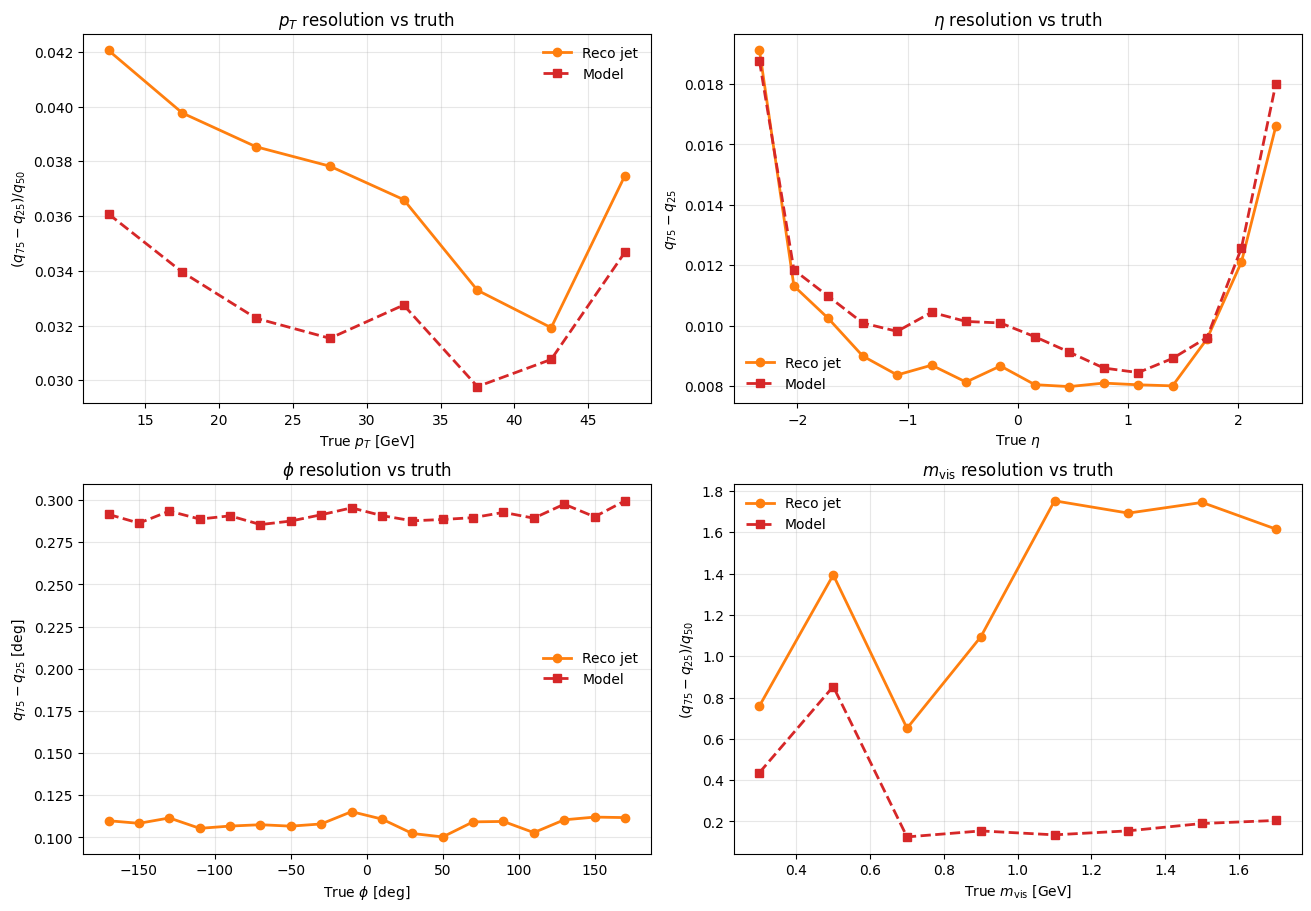

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
centers, vals, _ = compute_binned_stat(kin_true_pt, kin_pt_bins, kin_pt_ratio_reco, iqr_over_q50)
axes[0, 0].plot(centers, vals, marker='o', linewidth=2.0, color='tab:orange', label='Reco jet')
centers, vals, _ = compute_binned_stat(kin_true_pt, kin_pt_bins, kin_pt_ratio_model, iqr_over_q50)
axes[0, 0].plot(centers, vals, marker='s', linewidth=2.0, linestyle='--', color='tab:red', label='Model')
axes[0, 0].set_xlabel(r'True $p_T$ [GeV]')
axes[0, 0].set_ylabel(r'$(q_{75} - q_{25}) / q_{50}$')
axes[0, 0].set_title(r'$p_T$ resolution vs truth')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(frameon=False)
centers, vals, _ = compute_binned_stat(kin_true_eta, kin_eta_bins, kin_eta_residual_reco, iqr)
axes[0, 1].plot(centers, vals, marker='o', linewidth=2.0, color='tab:orange', label='Reco jet')
centers, vals, _ = compute_binned_stat(kin_true_eta, kin_eta_bins, kin_eta_residual_model, iqr)
axes[0, 1].plot(centers, vals, marker='s', linewidth=2.0, linestyle='--', color='tab:red', label='Model')
axes[0, 1].set_xlabel(r'True $\eta$')
axes[0, 1].set_ylabel(r'$q_{75} - q_{25}$')
axes[0, 1].set_title(r'$\eta$ resolution vs truth')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(frameon=False)
centers, vals, _ = compute_binned_stat(np.rad2deg(kin_true_phi), kin_phi_bins, kin_phi_residual_reco, iqr)
axes[1, 0].plot(centers, vals, marker='o', linewidth=2.0, color='tab:orange', label='Reco jet')
centers, vals, _ = compute_binned_stat(np.rad2deg(kin_true_phi), kin_phi_bins, kin_phi_residual_model, iqr)
axes[1, 0].plot(centers, vals, marker='s', linewidth=2.0, linestyle='--', color='tab:red', label='Model')
axes[1, 0].set_xlabel(r'True $\phi$ [deg]')
axes[1, 0].set_ylabel(r'$q_{75} - q_{25}$ [deg]')
axes[1, 0].set_title(r'$\phi$ resolution vs truth')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(frameon=False)
centers, vals, _ = compute_binned_stat(kin_true_mass, kin_mass_bins, kin_mass_ratio_reco, iqr_over_q50)
axes[1, 1].plot(centers, vals, marker='o', linewidth=2.0, color='tab:orange', label='Reco jet')
centers, vals, _ = compute_binned_stat(kin_true_mass, kin_mass_bins, kin_mass_ratio_model, iqr_over_q50)
axes[1, 1].plot(centers, vals, marker='s', linewidth=2.0, linestyle='--', color='tab:red', label='Model')
axes[1, 1].set_xlabel(r'True $m_{\mathrm{vis}}$ [GeV]')
axes[1, 1].set_ylabel(r'$(q_{75} - q_{25}) / q_{50}$')
axes[1, 1].set_title(r'$m_{\mathrm{vis}}$ resolution vs truth')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(frameon=False)
plt.show()


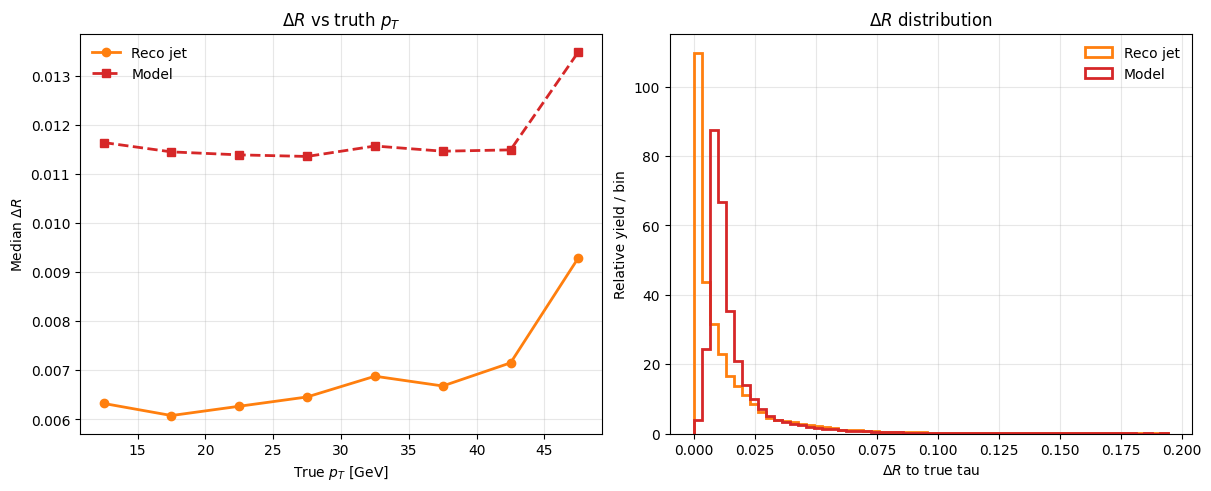

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
centers, vals, _ = compute_binned_stat(kin_true_pt, kin_pt_bins, kin_delta_r_reco, q50)
axes[0].plot(centers, vals, marker='o', linewidth=2.0, color='tab:orange', label='Reco jet')
centers, vals, _ = compute_binned_stat(kin_true_pt, kin_pt_bins, kin_delta_r_model, q50)
axes[0].plot(centers, vals, marker='s', linewidth=2.0, linestyle='--', color='tab:red', label='Model')
axes[0].set_xlabel(r'True $p_T$ [GeV]')
axes[0].set_ylabel(r'Median $\Delta R$')
axes[0].set_title(r'$\Delta R$ vs truth $p_T$')
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False)

bins = np.linspace(0.0, np.nanpercentile(np.concatenate([kin_delta_r_reco, kin_delta_r_model]), 99.5), 60)
axes[1].hist(kin_delta_r_reco, bins=bins, density=True, histtype='step', linewidth=2.0, color='tab:orange', label='Reco jet')
axes[1].hist(kin_delta_r_model, bins=bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label='Model')
axes[1].set_xlabel(r'$\Delta R$ to true tau')
axes[1].set_ylabel('Relative yield / bin')
axes[1].set_title(r'$\Delta R$ distribution')
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False)
plt.show()


### Kinematics Residual Distributions

Overlay the reco-jet and model residual / response distributions for the four kinematic components.


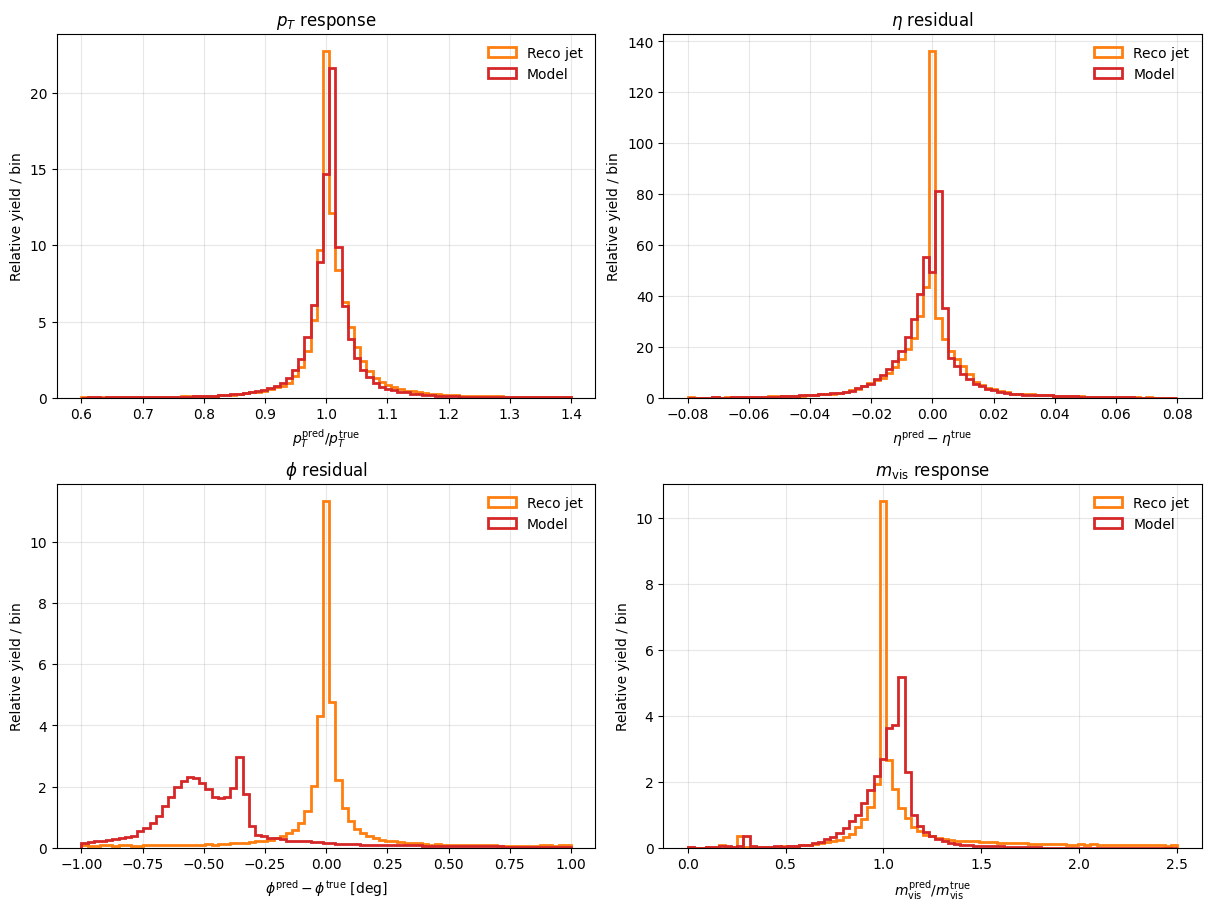

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

pt_bins = np.linspace(0.6, 1.4, 80)
eta_bins = np.linspace(-0.08, 0.08, 80)
phi_bins = np.linspace(-1.0, 1.0, 80)
mass_bins = np.linspace(0.0, 2.5, 80)

axes[0, 0].hist(kin_pt_ratio_reco, bins=pt_bins, density=True, histtype='step', linewidth=2.0, color='tab:orange', label='Reco jet')
axes[0, 0].hist(kin_pt_ratio_model, bins=pt_bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label='Model')
axes[0, 0].set_xlabel(r'$p_T^{\mathrm{pred}} / p_T^{\mathrm{true}}$')
axes[0, 0].set_ylabel('Relative yield / bin')
axes[0, 0].set_title(r'$p_T$ response')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(frameon=False)

axes[0, 1].hist(kin_eta_residual_reco, bins=eta_bins, density=True, histtype='step', linewidth=2.0, color='tab:orange', label='Reco jet')
axes[0, 1].hist(kin_eta_residual_model, bins=eta_bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label='Model')
axes[0, 1].set_xlabel(r'$\eta^{\mathrm{pred}} - \eta^{\mathrm{true}}$')
axes[0, 1].set_ylabel('Relative yield / bin')
axes[0, 1].set_title(r'$\eta$ residual')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(frameon=False)

axes[1, 0].hist(kin_phi_residual_reco, bins=phi_bins, density=True, histtype='step', linewidth=2.0, color='tab:orange', label='Reco jet')
axes[1, 0].hist(kin_phi_residual_model, bins=phi_bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label='Model')
axes[1, 0].set_xlabel(r'$\phi^{\mathrm{pred}} - \phi^{\mathrm{true}}$ [deg]')
axes[1, 0].set_ylabel('Relative yield / bin')
axes[1, 0].set_title(r'$\phi$ residual')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(frameon=False)

axes[1, 1].hist(kin_mass_ratio_reco, bins=mass_bins, density=True, histtype='step', linewidth=2.0, color='tab:orange', label='Reco jet')
axes[1, 1].hist(kin_mass_ratio_model, bins=mass_bins, density=True, histtype='step', linewidth=2.0, color='tab:red', label='Model')
axes[1, 1].set_xlabel(r'$m_{\mathrm{vis}}^{\mathrm{pred}} / m_{\mathrm{vis}}^{\mathrm{true}}$')
axes[1, 1].set_ylabel('Relative yield / bin')
axes[1, 1].set_title(r'$m_{\mathrm{vis}}$ response')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(frameon=False)

plt.show()


## Tau ID

In [96]:
sig_raw, sig_predictions, sig_targets, tag_cfg = infer_single_task('is_tau', CHECKPOINTS['is_tau'], SAMPLE_NAMES['signal'])
bkg_raw, bkg_predictions, bkg_targets, _ = infer_single_task('is_tau', CHECKPOINTS['is_tau'], SAMPLE_NAMES['background'])

tagging_yaml = OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/tagging.yaml')
metrics_yaml = OmegaConf.load(MLTAU_MODEL_REPO / 'mltau/config/metrics/metrics.yaml')
tag_eval_cfg = OmegaConf.create({
    'metrics': {
        'ALGORITHM_PLOT_STYLES': OmegaConf.to_container(metrics_yaml.ALGORITHM_PLOT_STYLES, resolve=True),
        'tagging': OmegaConf.to_container(tagging_yaml.tagging, resolve=True),
    }
})

tag_evaluator = tag_eval.TaggerEvaluator(
    signal_predictions=np.asarray(sig_predictions['is_tau']),
    signal_gen_tau_p4=ak.Array(sig_raw.gen_jet_tau_p4s),
    signal_reco_jet_p4=ak.Array(sig_raw.reco_jet_p4s),
    bkg_predictions=np.asarray(bkg_predictions['is_tau']),
    bkg_gen_jet_p4=ak.Array(bkg_raw.gen_jet_p4s),
    bkg_reco_jet_p4=ak.Array(bkg_raw.reco_jet_p4s),
    cfg=tag_eval_cfg,
    sample='all',
    algorithm='all',
)
display(pd.DataFrame([{
    'loose_wp': tag_evaluator.loose_wp,
    'medium_wp': tag_evaluator.medium_wp,
    'tight_wp': tag_evaluator.tight_wp,
}]))


There are 118,028 jets in the dataset.
There are 739,475 jets in the dataset.


,loose_wp,medium_wp,tight_wp
0,0.0000,0.1863,0.4479


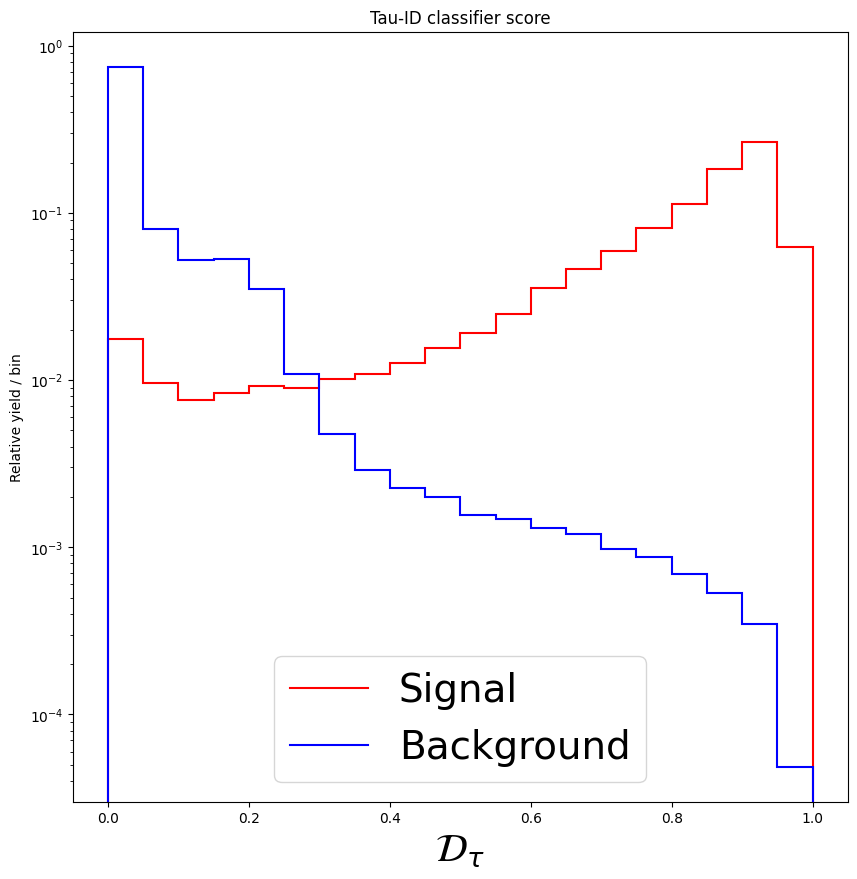

In [97]:
tag_classifier_plot = tag_eval.TauClassifierPlot()
tag_classifier_plot.add_line(tag_evaluator, dataset='test')
tag_classifier_plot.ax.set_title('Tau-ID classifier score')
plt.show()


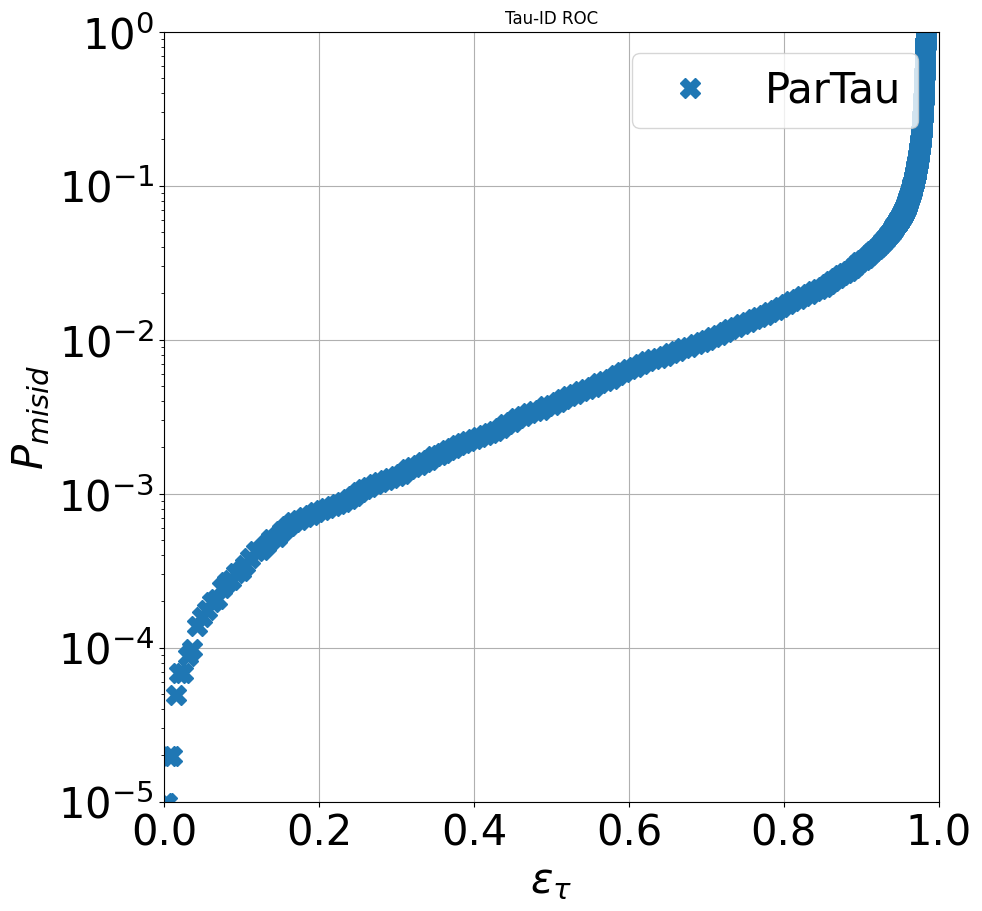

In [98]:
tag_roc_plot = tag_eval.ROCPlot(tag_eval_cfg)
tag_roc_plot.add_line(tag_evaluator)
tag_roc_plot.ax.set_title('Tau-ID ROC')
plt.show()


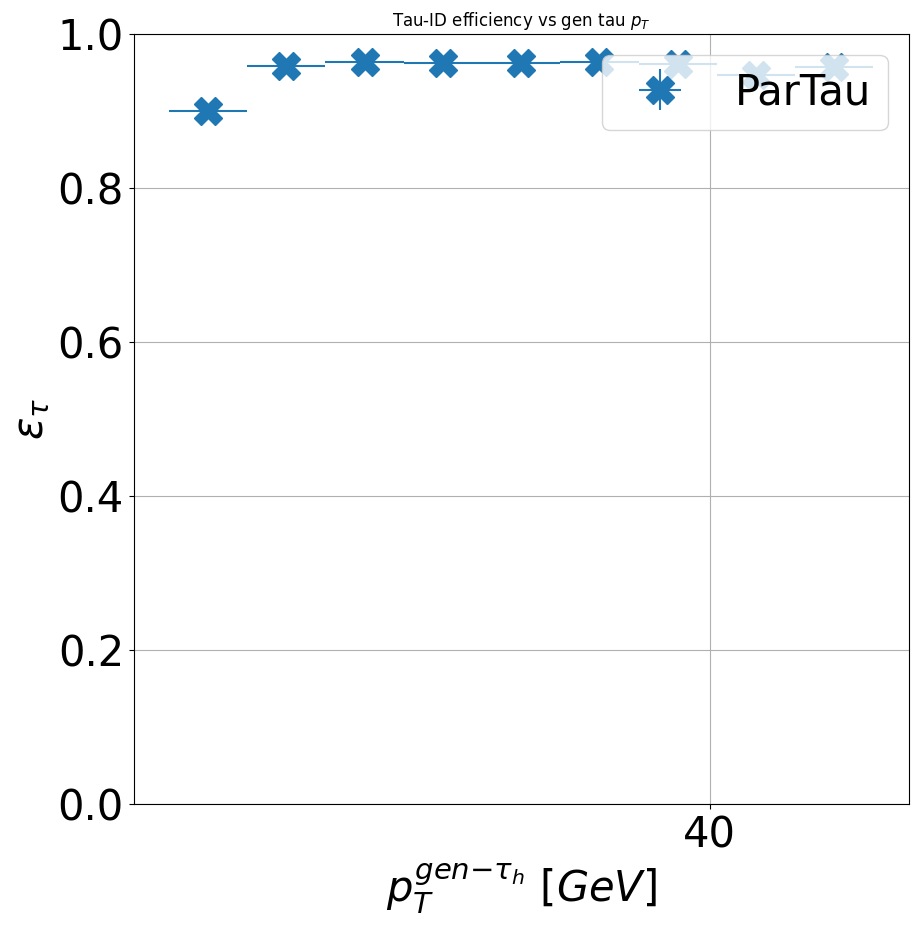

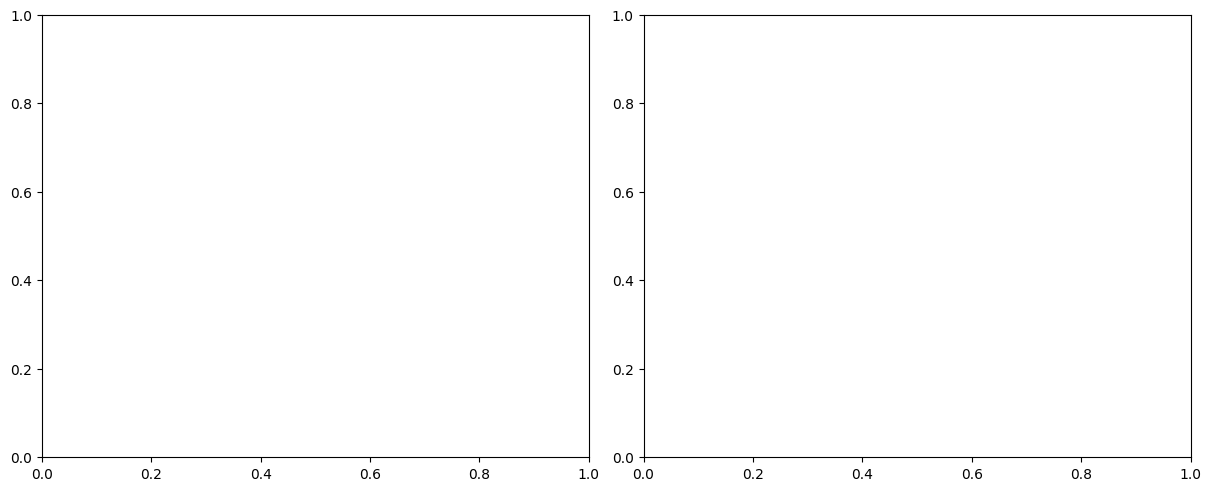

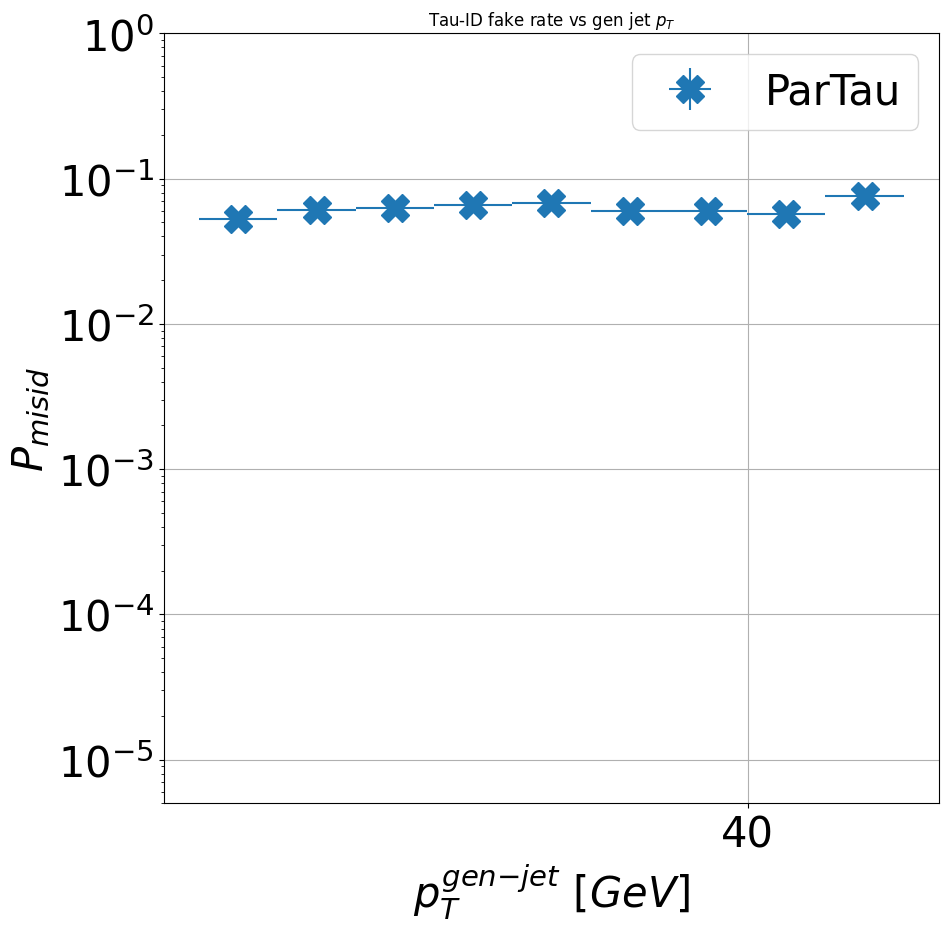

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
plt.sca(axes[0])
tag_eff_plot = tag_eval.EfficiencyPlot(tag_eval_cfg, 'pt')
tag_eff_plot.add_line(tag_evaluator)
tag_eff_plot.ax.set_title('Tau-ID efficiency vs gen tau $p_T$')
plt.sca(axes[1])
tag_fake_plot = tag_eval.FakeRatePlot(tag_eval_cfg, 'pt')
tag_fake_plot.add_line(tag_evaluator)
tag_fake_plot.ax.set_title('Tau-ID fake rate vs gen jet $p_T$')
plt.show()
